## Multimodal Day: Exercise 2

In [9]:
from io import BytesIO
import requests
import matplotlib.pyplot as plt
from PIL import Image

import torch
from transformers import BitsAndBytesConfig, GenerationConfig

from lxmls.multimodal.gemma3 import Gemma3ForConditionalGeneration, Gemma3Processor

In [2]:
quantization_config = BitsAndBytesConfig(load_in_4bit=True)
model = Gemma3ForConditionalGeneration.from_pretrained(
    "google/gemma-3-4b-it",
    quantization_config=quantization_config,
    torch_dtype=torch.bfloat16,
)
processor = Gemma3Processor.from_pretrained("google/gemma-3-4b-it")

2025-06-20 15:43:24,778 -  lxmls.multimodal.gemma3 -    INFO - text_config is None, using default Gemma3TextConfig text config.
2025-06-20 15:43:24,780 -  lxmls.multimodal.gemma3 -    INFO - vision_config is None, using default SiglipVisionConfig vision config.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


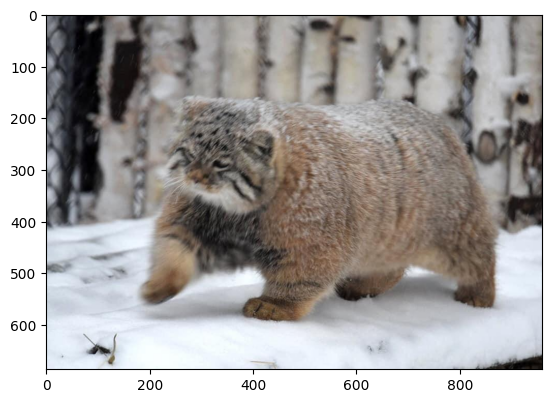

In [10]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = Image.open(BytesIO(requests.get(url, timeout=120).content))
plt.imshow(image)

In [11]:
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": "You are a helpful assistant who gives concise yet detailed answers."}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Is the cat chonky?"},
        ],
    },
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    add_generation_prompt=True,
).to(model.device)
generation_config = GenerationConfig(
    do_sample=False,
    max_new_tokens=64,
)
output_ids = model.generate(**inputs, generation_config=generation_config)
output_str = processor.batch_decode(
    output_ids[:, len(inputs["input_ids"].squeeze()) :],
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]
print(output_str)


Yes, the animal in the image appears to be quite chonky (or chubby). It has a rounded, substantial build, particularly evident in its fur and overall shape.
